# Benchmark
Here I will benchmark the two models, namely the linear Neural Network (NN) model and the MultiLayer Perception (MLP) models.

In [1]:
from importlib import reload
import MLPModel, LinearModel 
import Model_Training
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)
import torch

# Set randomization seed for controlled performance
seed = 22
torch.manual_seed(seed)

A typical training will look like:

In [3]:


ticker = "BTC-USD"
start = '2022-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.001
tx_fees_bpts = 10

max_lags = 4

modelMLP = MLPModel.MLP # multiplayer perception 

Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "sign",
                              threshold=0.001,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True)

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

ModelLin = Model_Training.model_training(model = modelLinear(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5 ,
                              trade_signal = "sign",
                              threshold=0.001,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True)



[*********************100%***********************]  1 of 1 completed



Training model...
Epoch 0/100000, Loss = 1.007076740
Epoch 500/100000, Loss = 0.958867550


[*********************100%***********************]  1 of 1 completed

Epoch 1000/100000, Loss = 0.931597412
Relative Tolance Reached at Epoch 1243

 Training Finished! 
 Loss = 0.907344580
Test Loss = 0.610622525

Test Loss = 0.000494126 
Train Loss = 0.000734196

Training model...
Epoch 0/100000, Loss = 1.382107854
Epoch 500/100000, Loss = 1.002101660
Relative Tolance Reached at Epoch 670

 Training Finished! 
 Loss = 0.997063041
Test Loss = 0.594636917

Test Loss = 0.000481191 
Train Loss = 0.000806833



Test Loss = 0.000494126 
Train Loss = 0.000734196

Test Loss = 0.000481191 
Train Loss = 0.000806833


Text(0.5, 1.0, 'Linear Model')

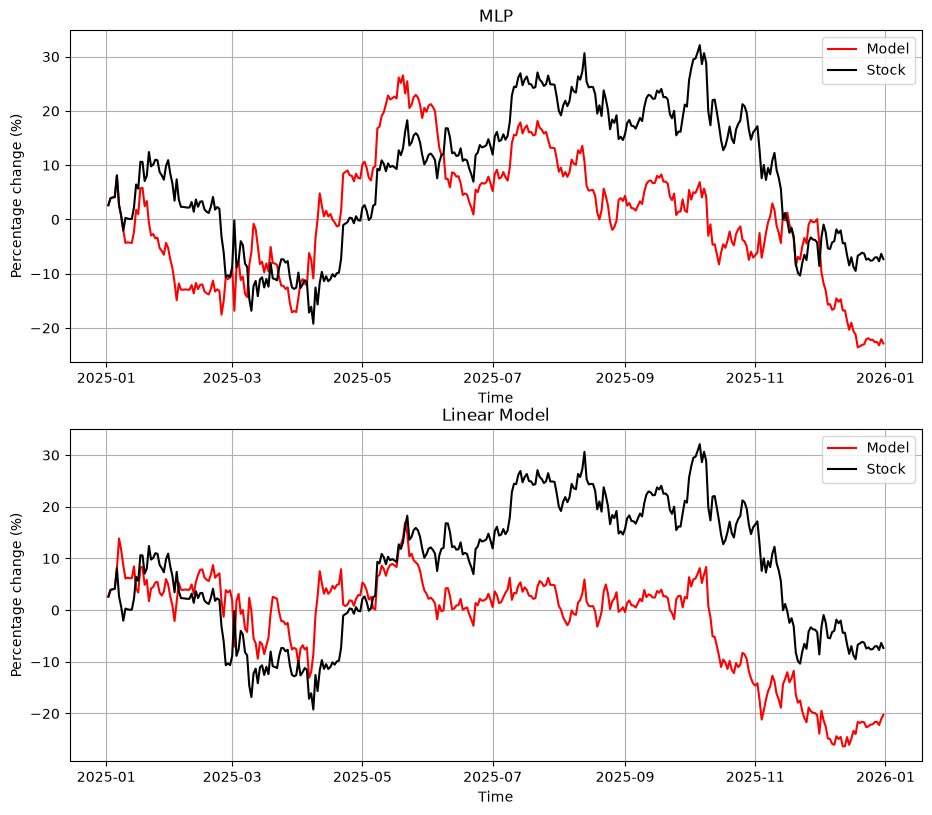

In [4]:

fx_fees_bpts = 0

import matplotlib.pyplot as plt
fig, (ax1,ax2) = plt.subplots(2,1, figsize = (11,9.5))

Model.get_trade_results("sign",0, fx_fees_bpts)
ModelLin.get_trade_results("sign",0, fx_fees_bpts)


Model.model_against_stock(ax1)
ModelLin.model_against_stock(ax2)

ax1.set_title("MLP")
ax2.set_title("Linear Model")

# Model.date_test

## Performace with different lookback

In [5]:
import pandas as pd 

lookbacks = range(1,64) # From one day to roughly above two months

df_LB = pd.DataFrame({}) # Generate the dataframe which we will append to in the end


ticker = "BTC-USD"
start = '2020-01-01'    # start date
end  = '2024-01-01'     # end date
interval = '1d'         # interval

train_ratio = 0.60
no_epoches = 100_000
lr = 0.0001
tx_cost = 10
atol = 1e-8

performance_results = [] # List which we will later fill with dataframes

for lb in lookbacks:
    # Train both the MLP and Linear models at lookback lb
    
    modelMLP = MLPModel.MLP # multiplayer perception 
    Model = Model_Training.model_training(model = modelMLP(lb),
                                tick = ticker,
                                start = start,
                                end = end ,
                                interval = interval,
                                train_ratio = train_ratio,
                                max_lags = lb,
                                no_epochs=no_epoches,
                                lr = lr,
                                rtol = 1e-5,
                                atol = atol,
                                trade_signal = "sign",
                                transaction_cost_bpts=tx_cost,
                                threshold=0.001)
    
    Model.get_model_performance(Model.trade_results)
    mlp_df = Model.performance_df 
    mlp_df.insert(0, "Model", "MLP")
    mlp_df.insert(1, "Lag", int(lb))
    
    performance_results.append(mlp_df)

    modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

    ModelLin = Model_Training.model_training(model = modelLinear(lb),
                                tick = ticker,
                                start = start,
                                end = end ,
                                interval = interval,
                                train_ratio = train_ratio,
                                max_lags = lb,
                                no_epochs=no_epoches,
                                lr = lr,
                                rtol = 1e-5 ,
                                atol = atol,
                                trade_signal = "sign",
                                transaction_cost_bpts=tx_cost,
                                threshold=0.001)
    
    ModelLin.get_model_performance(
        ModelLin.trade_results
    )
    linear_df = ModelLin.performance_df 
    
    linear_df.insert(0, "Model", "linear")
    linear_df.insert(1, "Lag", int(lb))
    
    performance_results.append(linear_df)
    
df_LB = pd.concat(
    performance_results,
    ignore_index=True,
)

        
    



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [78]:
df_LB

,Model,Lag,max_drawdown_log,drawdown_percentage,win_rate,average_win,average_loss,expected_value_per_trade,total_log_return,compounded_return,equity_multiplier,equity_trough,equity_peak,return_std,annualized_sharpe_stocks,annualized_sharpe_crypto
0,MLP,1,-1.016299,-0.638068,0.505137,0.026134,-0.027115,-0.000217,-0.126889,-0.119168,0.880832,-0.899419,0.329676,0.041329,-0.083454,-0.100437
1,linear,1,-0.892897,-0.590532,0.532534,0.024973,-0.028327,0.000057,0.033307,0.033868,1.033868,-0.719467,0.225451,0.041244,0.021951,0.026418
2,MLP,2,-2.252948,-0.894911,0.484589,0.023966,-0.029120,-0.003395,-1.982730,-0.862307,0.137693,-2.230465,0.022483,0.041180,-1.308772,-1.575108
3,linear,2,-0.817845,-0.558618,0.508562,0.026061,-0.027093,-0.000061,-0.035458,-0.034837,0.965163,-0.394816,0.423029,0.041268,-0.023356,-0.028109
4,MLP,3,-1.031642,-0.643579,0.514580,0.025616,-0.027455,-0.000146,-0.085002,-0.081489,0.918511,-1.004664,0.026978,0.041215,-0.056157,-0.067585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,linear,61,-2.474173,-0.915767,0.467857,0.023390,-0.027631,-0.003760,-2.105876,-0.878261,0.121739,-2.105876,0.368296,0.040025,-1.491479,-1.794996
122,MLP,62,-1.790488,-0.833121,0.480357,0.024606,-0.026664,-0.002036,-1.140110,-0.680216,0.319784,-1.159749,0.630739,0.040124,-0.805472,-0.969385
123,linear,62,-1.687519,-0.815022,0.489286,0.023629,-0.027447,-0.002456,-1.375400,-0.747261,0.252739,-1.420061,0.267458,0.040084,-0.972676,-1.170616
124,MLP,63,-0.672301,-0.489468,0.515206,0.026555,-0.024657,0.001727,0.965631,1.626443,2.626443,-0.140172,1.096121,0.040118,0.683541,0.822642


In [6]:
df_MLP = df_LB[df_LB["Model"] == "MLP"]
df_Lin = df_LB[df_LB["Model"] == "linear"]

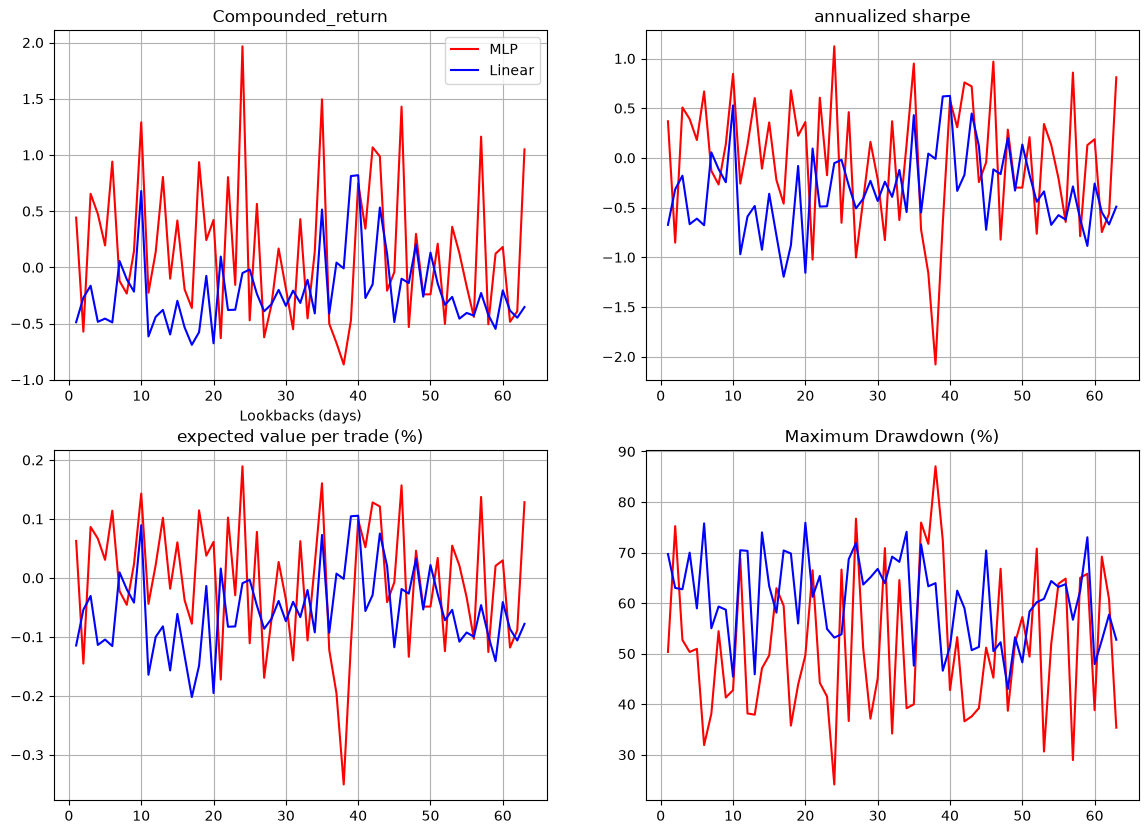

In [7]:
from matplotlib import pyplot as plt 

def draw_benchmarks(df_LB,lookbacks):
    df_MLP = df_LB[df_LB["Model"] == "MLP"]
    df_Lin = df_LB[df_LB["Model"] == "linear"]
    
    fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (14,10))
    
    axes = [ax1, ax2 ,ax3, ax4]
    ax1.plot(lookbacks, df_MLP["compounded_return"], label='MLP',c='r')
    ax1.plot(lookbacks, df_Lin["compounded_return"], label='Linear',c='blue')
    ax1.set_xlabel("Lookbacks (days)")
    ax1.set_title("Compounded_return")
    
    ax2.plot(lookbacks, df_MLP["annualized_sharpe_stocks"], label='MLP',c='r')
    ax2.plot(lookbacks, df_Lin["annualized_sharpe_stocks"], label='Linear',c='blue')
    ax2.set_title("annualized sharpe")
    
    ax3.plot(lookbacks, np.expm1(df_MLP["expected_value_per_trade"]) * 100, label="MLP", c='r')
    ax3.plot(lookbacks, np.expm1(df_Lin["expected_value_per_trade"]) * 100, label="Linear", c='blue')
    ax3.set_title("expected value per trade (%)")
    
    ax4.plot(lookbacks, -np.expm1(df_MLP["max_drawdown_log"]) * 100, label="MLP", c='r')
    ax4.plot(lookbacks, -np.expm1(df_Lin["max_drawdown_log"]) * 100, label="Linear", c='blue')
    ax4.set_title("Maximum Drawdown (%)")
    
    ax1.legend()
    for ax in axes:
        ax.grid(True)

    



# plt.plot(lookbacks,df_MLP["compounded_return"])
# plt.plot(lookbacks,df_Lin["compounded_return"])

draw_benchmarks(df_LB,lookbacks)
# df_MLP["compounded_return"].shape
# print(df_MLP.shape)